# Modality-Level Stacking Architecture for Binary Valence and Arousal Prediction

This notebook develops a modality-level stacking architecture for binary prediction of self-reported valence and arousal from video-level sensor-derived features.

The modeling task is formulated as binary classification. Numerical valence and arousal ratings are grouped into low, medium and high categories, and only low and high samples are retained. Medium samples are excluded from the binary classification task.

The architecture contains two supervised layers. In the first layer, separate models are trained on different sensor modalities, such as facial activation, EMG activation, expression intensity, breathing rate, HRV and motion-related features. Each modality-specific model produces prediction probabilities for low versus high affective response.

In the second layer, a meta-model combines the modality-level predictions into a final prediction. This allows the model to learn how different sensor modalities complement each other.

All evaluation is performed using Leave-One-Participant-Out cross-validation. For each held-out participant, the modality models and the meta-model are trained only on the remaining participants. Out-of-fold predictions within the training set are used to train the meta-model, preventing stacking leakage.

In [1]:
# Vnesuvanje na bibliotekite potrebni za preprocessing, grupiran cross-validation, treniranje na modeli, metriki i balansiranje na klasite.
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import LeaveOneGroupOut, GroupKFold

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import ExtraTreesClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 150)

Matplotlib is building the font cache; this may take a moment.


## 1. Loading the Clean Feature Dataset

The cleaned video-level dataset is loaded from the project output directory. Each row corresponds to one participant watching one empathy scene. The dataset contains self-reported valence and arousal ratings together with sensor-derived features extracted from the corresponding scene window.

In [2]:
# Go naogja korenskiot folder na proektot i go vcituva iscisteniot video-level dataset bez hardkodirana pateka.
CURRENT_DIR = Path.cwd().resolve()

PROJECT_ROOT = None
for candidate in [CURRENT_DIR, *CURRENT_DIR.parents]:
    if (candidate / "outputs").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not find project root. Make sure the notebook is inside the project folder."
    )

OUTPUT_DIR = PROJECT_ROOT / "outputs"
DATA_PATH = OUTPUT_DIR / "video_level_valence_arousal_minmax.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)
print("Dataset shape:", df.shape)

display(df.head())

Project root: C:\Users\Kristina's PC\Desktop\EmteqPRO-VR
Dataset path: C:\Users\Kristina's PC\Desktop\EmteqPRO-VR\outputs\video_level_valence_arousal_minmax.csv
Dataset shape: (384, 57)


,participant_id,participant_folder,recording_suffix,video_set,scene_name,scene_index,target_valence,target_arousal,target_discomfort,window_start,window_end,window_duration_seconds,segment_duration_seconds,trim_seconds_used,timing_source,feature_extraction_strategy,breathingrate_breathingrate_min,breathingrate_breathingrate_max,breathingrate_imu_motionintensity_min,breathingrate_imu_motionintensity_max,qc_breathingrate_ppg_quality_min,qc_breathingrate_ppg_quality_mean,emgactivation_emg_amplitude_zygo_weighted_min,emgactivation_emg_amplitude_zygo_weighted_max,emgactivation_emg_amplitude_orbi_weighted_min,emgactivation_emg_amplitude_orbi_weighted_max,emgactivation_emg_amplitude_front_weighted_min,emgactivation_emg_amplitude_front_weighted_max,emgactivation_emg_amplitude_corr_weighted_min,emgactivation_emg_amplitude_corr_weighted_max,expression_expression_intensity_min,expression_expression_intensity_max,expression_neutral_intensity_min,expression_neutral_intensity_max,facialactivation_facialactivation_min,facialactivation_facialactivation_max,hrv_hrv_mean_hr_min,hrv_hrv_mean_hr_max,hrv_hrv_rr_min,hrv_hrv_rr_max,hrv_hrv_sdnn_min,hrv_hrv_sdnn_max,hrv_hrv_sdsd_min,hrv_hrv_sdsd_max,hrv_hrv_rmssd_min,hrv_hrv_rmssd_max,hrv_imu_motionintensity_min,hrv_imu_motionintensity_max,qc_hrv_ppg_quality_min,qc_hrv_ppg_quality_mean,expression_smile_intensity_min,expression_smile_intensity_max,expression_eyebrow_raise_intensity_min,expression_eyebrow_raise_intensity_max,expression_frown_intensity_min,expression_frown_intensity_max,n_core_available_features
0,3,participant3,0,3,empathy_scene_1,1,1,3,1,1.704461e+09,1.704461e+09,120.0,200.0,40.0,details_start_end,split6_trimmed_fallback,10.446816,15.640528,0.0,0.846154,1.000000,1.000000,0.471619,74.557578,2.989772,193.801556,0.542198,28.991436,0.585319,16.507440,0.0,21.9,0.0,0.0,0.030521,0.425829,65.308989,73.409462,817.333333,918.709677,55.167892,139.210472,64.498062,177.132665,64.498062,177.180991,0.0,0.733333,1.0,1.0,5.5,21.9,0.0,0.0,7.4,8.3,28
1,3,participant3,0,3,empathy_scene_2,2,3,3,2,1.704461e+09,1.704461e+09,120.0,200.0,40.0,details_start_end,split6_trimmed_fallback,10.373120,15.919705,0.0,0.230769,1.000000,1.000000,0.758779,93.319921,2.326091,367.574970,-0.003053,59.168081,0.374244,12.118754,0.0,30.0,0.0,0.0,0.023948,0.722539,61.354020,75.227964,797.575758,977.931034,62.136443,122.216269,68.605959,132.837023,69.282032,132.842233,0.0,0.200000,1.0,1.0,4.4,30.0,13.1,21.3,0.0,0.0,28
2,3,participant3,0,3,empathy_scene_3,3,0,0,0,1.704461e+09,1.704461e+09,120.0,200.0,40.0,details_start_end,split6_trimmed_fallback,9.163744,15.569518,0.0,0.230769,1.000000,1.000000,4.026037,81.549640,12.058416,384.159678,-0.109454,63.268512,0.564494,23.403621,0.0,29.9,0.0,0.0,0.083460,0.664852,61.179898,72.727273,825.000000,980.714286,52.136573,119.990855,67.656543,157.585330,67.670602,158.065225,0.0,0.200000,1.0,1.0,4.5,29.9,0.0,0.0,0.0,0.0,28
3,3,participant3,0,3,empathy_scene_4,4,2,1,1,1.704461e+09,1.704461e+09,120.0,200.0,40.0,details_start_end,split6_trimmed_fallback,10.739601,14.466929,0.0,0.461538,0.978226,0.999453,2.112242,280.625786,7.264172,514.008341,-0.022390,24.817357,0.500666,14.036135,0.0,108.1,0.0,0.0,0.055702,1.687703,61.009818,69.915254,858.181818,983.448276,52.746775,123.979387,73.142475,158.307160,73.155479,158.401102,0.0,0.266667,1.0,1.0,5.0,108.1,0.0,0.0,0.0,0.0,28
4,4,participant4,0,1,empathy_scene_1,1,4,2,2,1.704737e+09,1.704737e+09,130.0,210.0,40.0,details_start_end,split6_trimmed_fallback,10.039688,14.118108,0.0,0.000000,1.000000,1.000000,2.737313,93.411802,0.376880,315.791773,0.190412,47.383158,0.851178,77.210891,0.0,0.0,0.0,0.0,0.027433,0.124473,89.743590,99.858357,600.851064,668.571429,23.385684,61.159173,28.791068,39.553271,28.919952,39.562828,0.0,0.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,28


In [3]:
# Ja proveruva strukturata i grupiranjeto na dataset-ot za da se potvrdat participant-level dizajnot i kompletnosta na target vrednostite.
print("Dataset shape:", df.shape)

print("\nNumber of participants:")
print(df["participant_id"].nunique())

print("\nRows by scene:")
display(df["scene_name"].value_counts().sort_index().to_frame("n_rows"))

print("\nRows by participant:")
rows_by_participant = (
    df.groupby(["participant_id", "participant_folder"])
    .size()
    .to_frame("n_rows")
    .reset_index()
)

display(rows_by_participant["n_rows"].describe())

print("\nMissing targets:")
target_cols = ["target_valence", "target_arousal"]

if "target_discomfort" in df.columns:
    target_cols.append("target_discomfort")

display(df[target_cols].isna().sum().to_frame("n_missing"))

Dataset shape: (384, 57)

Number of participants:
96

Rows by scene:


,n_rows
scene_name,
empathy_scene_1,96
empathy_scene_2,96
empathy_scene_3,96
empathy_scene_4,96



Rows by participant:


count    96.0
mean      4.0
std       0.0
min       4.0
25%       4.0
50%       4.0
75%       4.0
max       4.0
Name: n_rows, dtype: float64


Missing targets:


,n_missing
target_valence,0
target_arousal,0
target_discomfort,0


## 2. Binary Target Definition

The original valence and arousal ratings are converted into low, medium and high categories. Ratings from 0 to 1 are treated as low, rating 2 is treated as medium, and ratings greater than or equal to 3 are treated as high.

For binary classification, only low and high samples are retained. Medium samples are excluded because they represent an intermediate response level and may be less clearly separable from the sensor-derived features.

In [4]:
# Gi pretvora originalnite ocenki vo low, medium i high kategorii, a za binarna klasifikacija gi zadrzuva samo low i high primerocite.
def bin_low_medium_high(x):
    if pd.isna(x):
        return np.nan
    if x <= 1:
        return "low"
    if x == 2:
        return "medium"
    if x >= 3:
        return "high"
    return "unknown"


df["valence_category"] = df["target_valence"].apply(bin_low_medium_high)
df["arousal_category"] = df["target_arousal"].apply(bin_low_medium_high)

category_order = ["low", "medium", "high"]

print("Valence category counts:")
display(
    df["valence_category"]
    .value_counts()
    .reindex(category_order)
    .to_frame("count")
)

print("Arousal category counts:")
display(
    df["arousal_category"]
    .value_counts()
    .reindex(category_order)
    .to_frame("count")
)

Valence category counts:


,count
valence_category,
low,88
medium,82
high,214


Arousal category counts:


,count
arousal_category,
low,121
medium,131
high,132


In [5]:
# Gi definira metadata kolonite i gi odvojuva vistinskite sensor-derived features od labels i identifikatorite.
metadata_cols = {
    "participant_id",
    "participant_folder",
    "recording_suffix",
    "video_set",
    "scene_name",
    "scene_index",
    "target_valence",
    "target_arousal",
    "target_discomfort",
    "window_start",
    "window_end",
    "window_duration_seconds",
    "segment_duration_seconds",
    "trim_seconds_used",
    "timing_source",
    "feature_extraction_strategy",
    "valence_category",
    "arousal_category",
    "discomfort_category",
    "n_core_available_features",
}

feature_cols = [
    col for col in df.columns
    if col not in metadata_cols
    and not col.startswith("qc_")
]

print("Number of original sensor feature columns:", len(feature_cols))

display(pd.DataFrame({"feature": feature_cols}))

Number of original sensor feature columns: 36


,feature
0,breathingrate_breathingrate_min
1,breathingrate_breathingrate_max
2,breathingrate_imu_motionintensity_min
3,breathingrate_imu_motionintensity_max
4,emgactivation_emg_amplitude_zygo_weighted_min
5,emgactivation_emg_amplitude_zygo_weighted_max
6,emgactivation_emg_amplitude_orbi_weighted_min
7,emgactivation_emg_amplitude_orbi_weighted_max
8,emgactivation_emg_amplitude_front_weighted_min
9,emgactivation_emg_amplitude_front_weighted_max


## 3. Enhanced Sensor Feature Representation

The original dataset contains minimum and maximum values for each sensor-derived feature. To provide the models with a richer representation, mean and range features are created from each matching minimum-maximum feature pair.

The mean feature represents the average level of the signal within the scene window, while the range feature captures the spread between the minimum and maximum values. This step uses only input features and does not use target information.

In [6]:
# Kreira pobogata feature reprezentacija so dodavanje mean i range vrednosti za sekoj min/max sensorski par.
X_base = df[feature_cols].copy()
X_enhanced = X_base.copy()

for col in X_base.columns:
    if col.endswith("_min"):
        base = col.replace("_min", "")
        max_col = base + "_max"

        if max_col in X_base.columns:
            X_enhanced[f"{base}_mean"] = (
                X_base[col] + X_base[max_col]
            ) / 2

            X_enhanced[f"{base}_range"] = (
                X_base[max_col] - X_base[col]
            )

print("Original features:", X_base.shape[1])
print("Enhanced features:", X_enhanced.shape[1])
print("Added features:", X_enhanced.shape[1] - X_base.shape[1])

display(pd.DataFrame({"feature": X_enhanced.columns}))

Original features: 36
Enhanced features: 72
Added features: 36


,feature
0,breathingrate_breathingrate_min
1,breathingrate_breathingrate_max
2,breathingrate_imu_motionintensity_min
3,breathingrate_imu_motionintensity_max
4,emgactivation_emg_amplitude_zygo_weighted_min
5,emgactivation_emg_amplitude_zygo_weighted_max
6,emgactivation_emg_amplitude_orbi_weighted_min
7,emgactivation_emg_amplitude_orbi_weighted_max
8,emgactivation_emg_amplitude_front_weighted_min
9,emgactivation_emg_amplitude_front_weighted_max


## 4. Preparing Binary Valence and Arousal Datasets

Separate binary datasets are created for valence and arousal. For each target, samples labelled as medium are removed, and the remaining low and high samples are encoded as binary labels.

The participant identifier is preserved and used as the grouping variable for Leave-One-Participant-Out cross-validation.

In [7]:
# Kreira pomosna funkcija koja gi zadrzuva samo low/high nabljuduvanjata i gi vrakja X, y, participant grupite i metadata.
binary_label_mapping = {
    "low": 0,
    "high": 1,
}

inverse_binary_label_mapping = {
    0: "low",
    1: "high",
}

binary_label_order_numeric = [0, 1]
binary_label_order_names = ["low", "high"]


def prepare_binary_dataset(df, X, target_category_col):
    binary_mask = df[target_category_col].isin(["low", "high"])

    X_binary = X.loc[binary_mask].reset_index(drop=True)

    y_binary = (
        df.loc[binary_mask, target_category_col]
        .map(binary_label_mapping)
        .reset_index(drop=True)
    )

    groups_binary = (
        df.loc[binary_mask, "participant_id"]
        .reset_index(drop=True)
    )

    metadata_binary = (
        df.loc[
            binary_mask,
            [
                "participant_id",
                "participant_folder",
                "scene_name",
                "target_valence",
                "target_arousal",
                "valence_category",
                "arousal_category",
            ],
        ]
        .reset_index(drop=True)
    )

    return X_binary, y_binary, groups_binary, metadata_binary

In [8]:
# Podgotvuva posebni binarni dataset-i za valence i arousal, so zacuvano grupiranje po participant za LOPO evaluacija.
X_valence_binary, y_valence_binary, groups_valence_binary, valence_binary_metadata = prepare_binary_dataset(
    df=df,
    X=X_enhanced,
    target_category_col="valence_category",
)

X_arousal_binary, y_arousal_binary, groups_arousal_binary, arousal_binary_metadata = prepare_binary_dataset(
    df=df,
    X=X_enhanced,
    target_category_col="arousal_category",
)

print("Valence binary dataset:")
print("X shape:", X_valence_binary.shape)
print("Participants:", groups_valence_binary.nunique())
display(
    y_valence_binary
    .value_counts()
    .sort_index()
    .rename(index=inverse_binary_label_mapping)
    .to_frame("count")
)

print("\nArousal binary dataset:")
print("X shape:", X_arousal_binary.shape)
print("Participants:", groups_arousal_binary.nunique())
display(
    y_arousal_binary
    .value_counts()
    .sort_index()
    .rename(index=inverse_binary_label_mapping)
    .to_frame("count")
)

Valence binary dataset:
X shape: (302, 72)
Participants: 96


,count
valence_category,
low,88
high,214



Arousal binary dataset:
X shape: (253, 72)
Participants: 95


,count
arousal_category,
low,121
high,132


## 5. Defining Sensor Modality Groups

The enhanced feature set is divided into modality-specific groups. Each group represents a different type of physiological or behavioral signal. Separate first-layer models will be trained on each modality, and their prediction probabilities will later be combined by a second-layer meta-model.

In [9]:
# Gi deli features spored sensorski modality za sekoj model od prvoto nivo da uci samo od edna familija na signali.
def get_modality_feature_groups(feature_names):
    feature_names = list(feature_names)

    modality_groups = {
        "facial_activation": [
            col for col in feature_names
            if col.startswith("facialactivation")
        ],

        "emg_activation": [
            col for col in feature_names
            if col.startswith("emgactivation")
        ],

        "expression": [
            col for col in feature_names
            if col.startswith("expression")
        ],

        "breathing": [
            col for col in feature_names
            if col.startswith("breathingrate")
        ],

        "hrv": [
            col for col in feature_names
            if col.startswith("hrv")
        ],
    }

    assigned_features = sorted(
        {
            feature
            for group_features in modality_groups.values()
            for feature in group_features
        }
    )

    unassigned_features = sorted(
        set(feature_names) - set(assigned_features)
    )

    return modality_groups, unassigned_features


modality_feature_groups, unassigned_features = get_modality_feature_groups(
    X_enhanced.columns
)

for modality_name, modality_features in modality_feature_groups.items():
    print(f"{modality_name}: {len(modality_features)} features")

print("\nUnassigned features:")
print(unassigned_features)

facial_activation: 4 features
emg_activation: 16 features
expression: 20 features
breathing: 8 features
hrv: 24 features

Unassigned features:
[]


In [10]:
# Gi prikazuva feature grupite za jasno da se vidi koi familii na signali se modeliraat odvoeno.
for modality_name, modality_features in modality_feature_groups.items():
    print("\n" + "=" * 80)
    print(f"{modality_name} ({len(modality_features)} features)")
    print("=" * 80)

    display(pd.DataFrame({"feature": modality_features}))


facial_activation (4 features)


,feature
0,facialactivation_facialactivation_min
1,facialactivation_facialactivation_max
2,facialactivation_facialactivation_mean
3,facialactivation_facialactivation_range



emg_activation (16 features)


,feature
0,emgactivation_emg_amplitude_zygo_weighted_min
1,emgactivation_emg_amplitude_zygo_weighted_max
2,emgactivation_emg_amplitude_orbi_weighted_min
3,emgactivation_emg_amplitude_orbi_weighted_max
4,emgactivation_emg_amplitude_front_weighted_min
5,emgactivation_emg_amplitude_front_weighted_max
6,emgactivation_emg_amplitude_corr_weighted_min
7,emgactivation_emg_amplitude_corr_weighted_max
8,emgactivation_emg_amplitude_zygo_weighted_mean
9,emgactivation_emg_amplitude_zygo_weighted_range



expression (20 features)


,feature
0,expression_expression_intensity_min
1,expression_expression_intensity_max
2,expression_neutral_intensity_min
3,expression_neutral_intensity_max
4,expression_smile_intensity_min
5,expression_smile_intensity_max
6,expression_eyebrow_raise_intensity_min
7,expression_eyebrow_raise_intensity_max
8,expression_frown_intensity_min
9,expression_frown_intensity_max



breathing (8 features)


,feature
0,breathingrate_breathingrate_min
1,breathingrate_breathingrate_max
2,breathingrate_imu_motionintensity_min
3,breathingrate_imu_motionintensity_max
4,breathingrate_breathingrate_mean
5,breathingrate_breathingrate_range
6,breathingrate_imu_motionintensity_mean
7,breathingrate_imu_motionintensity_range



hrv (24 features)


,feature
0,hrv_hrv_mean_hr_min
1,hrv_hrv_mean_hr_max
2,hrv_hrv_rr_min
3,hrv_hrv_rr_max
4,hrv_hrv_sdnn_min
5,hrv_hrv_sdnn_max
6,hrv_hrv_sdsd_min
7,hrv_hrv_sdsd_max
8,hrv_hrv_rmssd_min
9,hrv_hrv_rmssd_max


logic (to prevent data leakage):

Outer LOPO:
    hold out one participant

    On the training participants only:
        Inner GroupKFold:
            train modality models
            generate out-of-fold modality probabilities

        train meta-model on those out-of-fold probabilities

    Fit modality models on full outer-train participants
    Predict modality probabilities for held-out participant
    Meta-model gives final prediction

## 6. Modality-Level Stacking Architecture

This section defines a two-layer supervised architecture.

In the first layer, separate models are trained for each sensor modality. Each modality model uses only the features from its own modality and outputs the predicted probability of the high class.

In the second layer, a meta-model combines the modality-level probabilities into a final low-versus-high prediction.

To avoid stacking leakage, the meta-model is trained using out-of-fold predictions generated within the training data of each outer Leave-One-Participant-Out fold. The held-out participant is never used to train either the modality models or the meta-model.

In [11]:
# Gi kreira base modelite za sekoj modality i meta-modelot koj gi kombinira nivnite verojatnosti.
def make_base_modality_pipeline(classifier, sampler=None):
    steps = [
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold()),
        ("scaler", StandardScaler()),
    ]

    if sampler is not None:
        steps.append(("sampler", sampler))
        steps.append(("classifier", classifier))
        return ImbPipeline(steps=steps)

    steps.append(("classifier", classifier))
    return Pipeline(steps=steps)


def build_base_modality_model(model_name, sampler=None):
    if model_name == "Logistic Regression":
        classifier = LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=42,
        )

    elif model_name == "RBF SVM":
        classifier = SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            class_weight="balanced",
            probability=True,
            random_state=42,
        )

    elif model_name == "Extra Trees":
        classifier = ExtraTreesClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=42,
            n_jobs=1,
        )

    elif model_name == "XGBoost":
        classifier = XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=2,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=1,
            verbosity=0,
        )

    else:
        raise ValueError(f"Unknown base model: {model_name}")

    return make_base_modality_pipeline(
        classifier=classifier,
        sampler=sampler,
    )


def build_meta_model():
    meta_model = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("classifier", LogisticRegression(
                max_iter=5000,
                class_weight="balanced",
                random_state=42,
            )),
        ]
    )

    return meta_model

In [12]:
def build_meta_model():
    meta_model = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("classifier", LogisticRegression(
                max_iter=5000,
                class_weight="balanced",
                random_state=42,
            )),
        ]
    )

    return meta_model

In [13]:
# Od verojatnostite za klasite ja izdvojuva verojatnosta za high klasata koja se koristi kako input vo meta-modelot.
def get_high_class_probability(fitted_model, X):
    probabilities = fitted_model.predict_proba(X)

    class_labels = list(fitted_model.classes_)

    if 1 not in class_labels:
        raise ValueError("The fitted model does not contain the high class label 1.")

    high_class_index = class_labels.index(1)

    return probabilities[:, high_class_index]

In [14]:
# Ja izveduva nested stacking postapkata: za sekoj outer participant fold generira probability features so inner CV, pa go trenira meta-modelot.
def get_nested_modality_stacking_predictions(
    X,
    y,
    groups,
    modality_feature_groups,
    base_model_name,
    sampler=None,
    inner_n_splits=5,
):
    X = X.reset_index(drop=True)
    y = pd.Series(y).reset_index(drop=True)
    groups = pd.Series(groups).reset_index(drop=True)

    outer_cv = LeaveOneGroupOut()

    y_pred = np.zeros(len(y), dtype=int)
    y_proba_high = np.zeros(len(y), dtype=float)

    modality_names = [
        modality_name
        for modality_name, features in modality_feature_groups.items()
        if len([feature for feature in features if feature in X.columns]) > 0
    ]

    meta_feature_names = [
        f"{modality_name}_proba_high"
        for modality_name in modality_names
    ]

    for outer_fold_index, (outer_train_idx, outer_test_idx) in enumerate(
        outer_cv.split(X, y, groups)
    ):
        print(
            f"Outer fold {outer_fold_index + 1}/{groups.nunique()}",
            end="\r",
        )

        X_outer_train = X.iloc[outer_train_idx].reset_index(drop=True)
        X_outer_test = X.iloc[outer_test_idx].reset_index(drop=True)

        y_outer_train = y.iloc[outer_train_idx].reset_index(drop=True)
        groups_outer_train = groups.iloc[outer_train_idx].reset_index(drop=True)

        meta_train = np.zeros(
            (
                len(X_outer_train),
                len(modality_names),
            )
        )

        meta_test = np.zeros(
            (
                len(X_outer_test),
                len(modality_names),
            )
        )

        n_inner_splits = min(
            inner_n_splits,
            groups_outer_train.nunique(),
        )

        inner_cv = GroupKFold(n_splits=n_inner_splits)

        for modality_index, modality_name in enumerate(modality_names):
            modality_features = [
                feature
                for feature in modality_feature_groups[modality_name]
                if feature in X.columns
            ]

            X_train_modality = X_outer_train[modality_features]
            X_test_modality = X_outer_test[modality_features]

            # Inner out-of-fold predviduvanja za treniranje na meta-modelot
            for inner_train_idx, inner_valid_idx in inner_cv.split(
                X_train_modality,
                y_outer_train,
                groups_outer_train,
            ):
                X_inner_train = X_train_modality.iloc[inner_train_idx]
                X_inner_valid = X_train_modality.iloc[inner_valid_idx]

                y_inner_train = y_outer_train.iloc[inner_train_idx]

                base_model_inner = build_base_modality_model(
                    model_name=base_model_name,
                    sampler=sampler,
                )

                base_model_inner.fit(
                    X_inner_train,
                    y_inner_train,
                )

                meta_train[
                    inner_valid_idx,
                    modality_index,
                ] = get_high_class_probability(
                    base_model_inner,
                    X_inner_valid,
                )

            # Treniranje na modality modelot vrz celosnite outer training podatoci
            base_model_full = build_base_modality_model(
                model_name=base_model_name,
                sampler=sampler,
            )

            base_model_full.fit(
                X_train_modality,
                y_outer_train,
            )

            meta_test[
                :,
                modality_index,
            ] = get_high_class_probability(
                base_model_full,
                X_test_modality,
            )

        meta_model = build_meta_model()

        meta_model.fit(
            meta_train,
            y_outer_train,
        )

        y_pred[outer_test_idx] = meta_model.predict(meta_test)
        y_proba_high[outer_test_idx] = get_high_class_probability(
            meta_model,
            meta_test,
        )

    print()

    return y_pred, y_proba_high, meta_feature_names

In [15]:
# Gi definira konfiguraciite na modeli sto ke se sporeduvaat vo stacking eksperimentite.
stacking_experiments = {
    "modality_logreg_no_sampling": {
        "base_model_name": "Logistic Regression",
        "sampler": None,
        "description": "Modality-level Logistic Regression models, no oversampling",
    },

    "modality_logreg_random_oversampling": {
        "base_model_name": "Logistic Regression",
        "sampler": RandomOverSampler(random_state=42),
        "description": "Modality-level Logistic Regression models, random oversampling",
    },

    "modality_rbf_svm_no_sampling": {
        "base_model_name": "RBF SVM",
        "sampler": None,
        "description": "Modality-level RBF SVM models, no oversampling",
    },

    "modality_rbf_svm_random_oversampling": {
        "base_model_name": "RBF SVM",
        "sampler": RandomOverSampler(random_state=42),
        "description": "Modality-level RBF SVM models, random oversampling",
    },

    "modality_extra_trees_no_sampling": {
        "base_model_name": "Extra Trees",
        "sampler": None,
        "description": "Modality-level Extra Trees models, no oversampling",
    },

    "modality_extra_trees_random_oversampling": {
        "base_model_name": "Extra Trees",
        "sampler": RandomOverSampler(random_state=42),
        "description": "Modality-level Extra Trees models, random oversampling",
    },

    "modality_xgboost_no_sampling": {
        "base_model_name": "XGBoost",
        "sampler": None,
        "description": "Modality-level XGBoost models, no oversampling",
    },

    "modality_xgboost_random_oversampling": {
        "base_model_name": "XGBoost",
        "sampler": RandomOverSampler(random_state=42),
        "description": "Modality-level XGBoost models, random oversampling",
    },
}

for experiment_name, config in stacking_experiments.items():
    print(experiment_name, "→", config["description"])

modality_logreg_no_sampling → Modality-level Logistic Regression models, no oversampling
modality_logreg_random_oversampling → Modality-level Logistic Regression models, random oversampling
modality_rbf_svm_no_sampling → Modality-level RBF SVM models, no oversampling
modality_rbf_svm_random_oversampling → Modality-level RBF SVM models, random oversampling
modality_extra_trees_no_sampling → Modality-level Extra Trees models, no oversampling
modality_extra_trees_random_oversampling → Modality-level Extra Trees models, random oversampling
modality_xgboost_no_sampling → Modality-level XGBoost models, no oversampling
modality_xgboost_random_oversampling → Modality-level XGBoost models, random oversampling


In [16]:
# Go evaluira sekoj eksperiment so ista LOPO postapka i gi sobira metrikite za sporedba na konfiguraciite.
def evaluate_modality_stacking_experiments(
    X,
    y,
    groups,
    modality_feature_groups,
    experiments,
    target_name,
    inner_n_splits=5,
):
    all_results = []
    all_predictions = {}

    for experiment_name, experiment_config in experiments.items():
        print("\n" + "=" * 90)
        print(f"Target: {target_name}")
        print(f"Experiment: {experiment_name}")
        print(experiment_config["description"])
        print("=" * 90)

        y_pred, y_proba_high, meta_feature_names = get_nested_modality_stacking_predictions(
            X=X,
            y=y,
            groups=groups,
            modality_feature_groups=modality_feature_groups,
            base_model_name=experiment_config["base_model_name"],
            sampler=experiment_config["sampler"],
            inner_n_splits=inner_n_splits,
        )

        cm = confusion_matrix(
            y,
            y_pred,
            labels=binary_label_order_numeric,
        )

        tn, fp, fn, tp = cm.ravel()

        result = {
            "target": target_name,
            "experiment": experiment_name,
            "base_model": experiment_config["base_model_name"],
            "sampling": "random_oversampling"
            if experiment_config["sampler"] is not None
            else "no_sampling",
            "meta_model": "Logistic Regression",
            "n_modalities": len(meta_feature_names),
            "accuracy": accuracy_score(y, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y, y_pred),
            "macro_f1": f1_score(
                y,
                y_pred,
                average="macro",
                zero_division=0,
            ),
            "weighted_f1": f1_score(
                y,
                y_pred,
                average="weighted",
                zero_division=0,
            ),
            "precision_low": precision_score(
                y,
                y_pred,
                pos_label=0,
                zero_division=0,
            ),
            "recall_low": recall_score(
                y,
                y_pred,
                pos_label=0,
                zero_division=0,
            ),
            "precision_high": precision_score(
                y,
                y_pred,
                pos_label=1,
                zero_division=0,
            ),
            "recall_high": recall_score(
                y,
                y_pred,
                pos_label=1,
                zero_division=0,
            ),
            "true_low": int((y == 0).sum()),
            "true_high": int((y == 1).sum()),
            "predicted_low": int((y_pred == 0).sum()),
            "predicted_high": int((y_pred == 1).sum()),
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
            "n_samples": len(y),
            "n_groups": groups.nunique(),
        }

        all_results.append(result)

        all_predictions[
            (
                target_name,
                experiment_name,
            )
        ] = {
            "y_pred": y_pred,
            "y_proba_high": y_proba_high,
            "meta_feature_names": meta_feature_names,
        }

    results_df = (
        pd.DataFrame(all_results)
        .sort_values(
            by=["target", "macro_f1", "balanced_accuracy"],
            ascending=[True, False, False],
        )
        .reset_index(drop=True)
    )

    return results_df, all_predictions

In [17]:
# Gi ogranicuva eksperimentite na najdobrite kandidati za sporedbata da ostane pregledna i presmetkovno izvodliva.
stacking_experiments_to_run = {
    "modality_logreg_no_sampling": stacking_experiments["modality_logreg_no_sampling"],

    "modality_extra_trees_no_sampling": stacking_experiments["modality_extra_trees_no_sampling"],

    "modality_extra_trees_random_oversampling": stacking_experiments[
        "modality_extra_trees_random_oversampling"
    ],

    "modality_xgboost_no_sampling": stacking_experiments["modality_xgboost_no_sampling"],

    "modality_xgboost_random_oversampling": stacking_experiments[
        "modality_xgboost_random_oversampling"
    ],
}

for experiment_name, config in stacking_experiments_to_run.items():
    print(experiment_name, "→", config["description"])

modality_logreg_no_sampling → Modality-level Logistic Regression models, no oversampling
modality_extra_trees_no_sampling → Modality-level Extra Trees models, no oversampling
modality_extra_trees_random_oversampling → Modality-level Extra Trees models, random oversampling
modality_xgboost_no_sampling → Modality-level XGBoost models, no oversampling
modality_xgboost_random_oversampling → Modality-level XGBoost models, random oversampling


In [18]:
# Ja izvrsuva celosnata LOPO modality-stacking evaluacija za valence i ja kreira tabelata za sporedba.
valence_stacking_results, valence_stacking_predictions = evaluate_modality_stacking_experiments(
    X=X_valence_binary,
    y=y_valence_binary,
    groups=groups_valence_binary,
    modality_feature_groups=modality_feature_groups,
    experiments=stacking_experiments_to_run,
    target_name="valence_binary",
    inner_n_splits=5,
)

display(valence_stacking_results)


Target: valence_binary
Experiment: modality_logreg_no_sampling
Modality-level Logistic Regression models, no oversampling
Outer fold 96/96

Target: valence_binary
Experiment: modality_extra_trees_no_sampling
Modality-level Extra Trees models, no oversampling
Outer fold 96/96

Target: valence_binary
Experiment: modality_extra_trees_random_oversampling
Modality-level Extra Trees models, random oversampling
Outer fold 96/96

Target: valence_binary
Experiment: modality_xgboost_no_sampling
Modality-level XGBoost models, no oversampling
Outer fold 96/96

Target: valence_binary
Experiment: modality_xgboost_random_oversampling
Modality-level XGBoost models, random oversampling
Outer fold 96/96


,target,experiment,base_model,sampling,meta_model,n_modalities,accuracy,balanced_accuracy,macro_f1,weighted_f1,precision_low,recall_low,precision_high,recall_high,true_low,true_high,predicted_low,predicted_high,tn,fp,fn,tp,n_samples,n_groups
0,valence_binary,modality_extra_trees_no_sampling,Extra Trees,no_sampling,Logistic Regression,5,0.715232,0.705395,0.683222,0.725235,0.508475,0.681818,0.847826,0.728972,88,214,118,184,60,28,58,156,302,96
1,valence_binary,modality_logreg_no_sampling,Logistic Regression,no_sampling,Logistic Regression,5,0.692053,0.679004,0.658234,0.703089,0.478992,0.647727,0.830601,0.710280,88,214,119,183,57,31,62,152,302,96
2,valence_binary,modality_xgboost_no_sampling,XGBoost,no_sampling,Logistic Regression,5,0.695364,0.674650,0.657849,0.705118,0.482456,0.625000,0.824468,0.724299,88,214,114,188,55,33,59,155,302,96
3,valence_binary,modality_xgboost_random_oversampling,XGBoost,random_oversampling,Logistic Regression,5,0.675497,0.677358,0.648286,0.689102,0.461538,0.681818,0.837209,0.672897,88,214,130,172,60,28,70,144,302,96
4,valence_binary,modality_extra_trees_random_oversampling,Extra Trees,random_oversampling,Logistic Regression,5,0.678808,0.666313,0.645158,0.690748,0.462810,0.636364,0.823204,0.696262,88,214,121,181,56,32,65,149,302,96


In [19]:
# Gi sortira valence eksperimentite spored Macro F1 za najdobrite stacking postavki polesno da se identifikuvaat.
display(
    valence_stacking_results
    .sort_values(
        by=["macro_f1", "balanced_accuracy"],
        ascending=False,
    )
    .head(10)
)

,target,experiment,base_model,sampling,meta_model,n_modalities,accuracy,balanced_accuracy,macro_f1,weighted_f1,precision_low,recall_low,precision_high,recall_high,true_low,true_high,predicted_low,predicted_high,tn,fp,fn,tp,n_samples,n_groups
0,valence_binary,modality_extra_trees_no_sampling,Extra Trees,no_sampling,Logistic Regression,5,0.715232,0.705395,0.683222,0.725235,0.508475,0.681818,0.847826,0.728972,88,214,118,184,60,28,58,156,302,96
1,valence_binary,modality_logreg_no_sampling,Logistic Regression,no_sampling,Logistic Regression,5,0.692053,0.679004,0.658234,0.703089,0.478992,0.647727,0.830601,0.710280,88,214,119,183,57,31,62,152,302,96
2,valence_binary,modality_xgboost_no_sampling,XGBoost,no_sampling,Logistic Regression,5,0.695364,0.674650,0.657849,0.705118,0.482456,0.625000,0.824468,0.724299,88,214,114,188,55,33,59,155,302,96
3,valence_binary,modality_xgboost_random_oversampling,XGBoost,random_oversampling,Logistic Regression,5,0.675497,0.677358,0.648286,0.689102,0.461538,0.681818,0.837209,0.672897,88,214,130,172,60,28,70,144,302,96
4,valence_binary,modality_extra_trees_random_oversampling,Extra Trees,random_oversampling,Logistic Regression,5,0.678808,0.666313,0.645158,0.690748,0.462810,0.636364,0.823204,0.696262,88,214,121,181,56,32,65,149,302,96


In [20]:
# Ja izvrsuva istata evaluacija za arousal za da se proveri dali najdobrata modality-stacking postavka zavisi od target-ot.
arousal_stacking_results, arousal_stacking_predictions = evaluate_modality_stacking_experiments(
    X=X_arousal_binary,
    y=y_arousal_binary,
    groups=groups_arousal_binary,
    modality_feature_groups=modality_feature_groups,
    experiments=stacking_experiments_to_run,
    target_name="arousal_binary",
    inner_n_splits=5,
)

display(arousal_stacking_results)


Target: arousal_binary
Experiment: modality_logreg_no_sampling
Modality-level Logistic Regression models, no oversampling
Outer fold 95/95

Target: arousal_binary
Experiment: modality_extra_trees_no_sampling
Modality-level Extra Trees models, no oversampling
Outer fold 95/95

Target: arousal_binary
Experiment: modality_extra_trees_random_oversampling
Modality-level Extra Trees models, random oversampling
Outer fold 95/95

Target: arousal_binary
Experiment: modality_xgboost_no_sampling
Modality-level XGBoost models, no oversampling
Outer fold 95/95

Target: arousal_binary
Experiment: modality_xgboost_random_oversampling
Modality-level XGBoost models, random oversampling
Outer fold 95/95


,target,experiment,base_model,sampling,meta_model,n_modalities,accuracy,balanced_accuracy,macro_f1,weighted_f1,precision_low,recall_low,precision_high,recall_high,true_low,true_high,predicted_low,predicted_high,tn,fp,fn,tp,n_samples,n_groups
0,arousal_binary,modality_logreg_no_sampling,Logistic Regression,no_sampling,Logistic Regression,5,0.462451,0.461777,0.461769,0.462602,0.439024,0.446281,0.484615,0.477273,121,132,123,130,54,67,69,63,253,95
1,arousal_binary,modality_xgboost_random_oversampling,XGBoost,random_oversampling,Logistic Regression,5,0.430830,0.429063,0.428822,0.430295,0.401709,0.388430,0.455882,0.469697,121,132,117,136,47,74,70,62,253,95
2,arousal_binary,modality_extra_trees_no_sampling,Extra Trees,no_sampling,Logistic Regression,5,0.426877,0.426309,0.426304,0.427093,0.403226,0.413223,0.449612,0.439394,121,132,124,129,50,71,74,58,253,95
3,arousal_binary,modality_xgboost_no_sampling,XGBoost,no_sampling,Logistic Regression,5,0.426877,0.425620,0.425585,0.426770,0.400000,0.396694,0.451128,0.454545,121,132,120,133,48,73,72,60,253,95
4,arousal_binary,modality_extra_trees_random_oversampling,Extra Trees,random_oversampling,Logistic Regression,5,0.422925,0.421488,0.421397,0.422690,0.394958,0.388430,0.447761,0.454545,121,132,119,134,47,74,72,60,253,95


In [21]:
# Gi rangira arousal eksperimentite na ist nacin za nivnite performansi direktno da se sporedat.
display(
    arousal_stacking_results
    .sort_values(
        by=["macro_f1", "balanced_accuracy"],
        ascending=False,
    )
    .head(10)
)

,target,experiment,base_model,sampling,meta_model,n_modalities,accuracy,balanced_accuracy,macro_f1,weighted_f1,precision_low,recall_low,precision_high,recall_high,true_low,true_high,predicted_low,predicted_high,tn,fp,fn,tp,n_samples,n_groups
0,arousal_binary,modality_logreg_no_sampling,Logistic Regression,no_sampling,Logistic Regression,5,0.462451,0.461777,0.461769,0.462602,0.439024,0.446281,0.484615,0.477273,121,132,123,130,54,67,69,63,253,95
1,arousal_binary,modality_xgboost_random_oversampling,XGBoost,random_oversampling,Logistic Regression,5,0.430830,0.429063,0.428822,0.430295,0.401709,0.388430,0.455882,0.469697,121,132,117,136,47,74,70,62,253,95
2,arousal_binary,modality_extra_trees_no_sampling,Extra Trees,no_sampling,Logistic Regression,5,0.426877,0.426309,0.426304,0.427093,0.403226,0.413223,0.449612,0.439394,121,132,124,129,50,71,74,58,253,95
3,arousal_binary,modality_xgboost_no_sampling,XGBoost,no_sampling,Logistic Regression,5,0.426877,0.425620,0.425585,0.426770,0.400000,0.396694,0.451128,0.454545,121,132,120,133,48,73,72,60,253,95
4,arousal_binary,modality_extra_trees_random_oversampling,Extra Trees,random_oversampling,Logistic Regression,5,0.422925,0.421488,0.421397,0.422690,0.394958,0.388430,0.447761,0.454545,121,132,119,134,47,74,72,60,253,95


In [22]:
# Gi spojuva tabelite so valence i arousal rezultati za dvete klasifikaciski zadaci direktno da se sporedat.
stacking_results = pd.concat(
    [
        valence_stacking_results,
        arousal_stacking_results,
    ],
    ignore_index=True,
)

stacking_results = (
    stacking_results
    .sort_values(
        by=["target", "macro_f1", "balanced_accuracy"],
        ascending=[True, False, False],
    )
    .reset_index(drop=True)
)

display(stacking_results)

,target,experiment,base_model,sampling,meta_model,n_modalities,accuracy,balanced_accuracy,macro_f1,weighted_f1,precision_low,recall_low,precision_high,recall_high,true_low,true_high,predicted_low,predicted_high,tn,fp,fn,tp,n_samples,n_groups
0,arousal_binary,modality_logreg_no_sampling,Logistic Regression,no_sampling,Logistic Regression,5,0.462451,0.461777,0.461769,0.462602,0.439024,0.446281,0.484615,0.477273,121,132,123,130,54,67,69,63,253,95
1,arousal_binary,modality_xgboost_random_oversampling,XGBoost,random_oversampling,Logistic Regression,5,0.430830,0.429063,0.428822,0.430295,0.401709,0.388430,0.455882,0.469697,121,132,117,136,47,74,70,62,253,95
2,arousal_binary,modality_extra_trees_no_sampling,Extra Trees,no_sampling,Logistic Regression,5,0.426877,0.426309,0.426304,0.427093,0.403226,0.413223,0.449612,0.439394,121,132,124,129,50,71,74,58,253,95
3,arousal_binary,modality_xgboost_no_sampling,XGBoost,no_sampling,Logistic Regression,5,0.426877,0.425620,0.425585,0.426770,0.400000,0.396694,0.451128,0.454545,121,132,120,133,48,73,72,60,253,95
4,arousal_binary,modality_extra_trees_random_oversampling,Extra Trees,random_oversampling,Logistic Regression,5,0.422925,0.421488,0.421397,0.422690,0.394958,0.388430,0.447761,0.454545,121,132,119,134,47,74,72,60,253,95
5,valence_binary,modality_extra_trees_no_sampling,Extra Trees,no_sampling,Logistic Regression,5,0.715232,0.705395,0.683222,0.725235,0.508475,0.681818,0.847826,0.728972,88,214,118,184,60,28,58,156,302,96
6,valence_binary,modality_logreg_no_sampling,Logistic Regression,no_sampling,Logistic Regression,5,0.692053,0.679004,0.658234,0.703089,0.478992,0.647727,0.830601,0.710280,88,214,119,183,57,31,62,152,302,96
7,valence_binary,modality_xgboost_no_sampling,XGBoost,no_sampling,Logistic Regression,5,0.695364,0.674650,0.657849,0.705118,0.482456,0.625000,0.824468,0.724299,88,214,114,188,55,33,59,155,302,96
8,valence_binary,modality_xgboost_random_oversampling,XGBoost,random_oversampling,Logistic Regression,5,0.675497,0.677358,0.648286,0.689102,0.461538,0.681818,0.837209,0.672897,88,214,130,172,60,28,70,144,302,96
9,valence_binary,modality_extra_trees_random_oversampling,Extra Trees,random_oversampling,Logistic Regression,5,0.678808,0.666313,0.645158,0.690748,0.462810,0.636364,0.823204,0.696262,88,214,121,181,56,32,65,149,302,96


In [23]:
# Gi zadrzuva samo nekolkute najdobri modeli za sekoj target za da gi istakne najdobrite kandidati bez nepotrebna prenatrupanost.
best_stacking_models_per_target = (
    stacking_results
    .sort_values(
        by=["target", "macro_f1", "balanced_accuracy"],
        ascending=[True, False, False],
    )
    .groupby("target")
    .head(5)
    .reset_index(drop=True)
)

display(best_stacking_models_per_target)

,target,experiment,base_model,sampling,meta_model,n_modalities,accuracy,balanced_accuracy,macro_f1,weighted_f1,precision_low,recall_low,precision_high,recall_high,true_low,true_high,predicted_low,predicted_high,tn,fp,fn,tp,n_samples,n_groups
0,arousal_binary,modality_logreg_no_sampling,Logistic Regression,no_sampling,Logistic Regression,5,0.462451,0.461777,0.461769,0.462602,0.439024,0.446281,0.484615,0.477273,121,132,123,130,54,67,69,63,253,95
1,arousal_binary,modality_xgboost_random_oversampling,XGBoost,random_oversampling,Logistic Regression,5,0.430830,0.429063,0.428822,0.430295,0.401709,0.388430,0.455882,0.469697,121,132,117,136,47,74,70,62,253,95
2,arousal_binary,modality_extra_trees_no_sampling,Extra Trees,no_sampling,Logistic Regression,5,0.426877,0.426309,0.426304,0.427093,0.403226,0.413223,0.449612,0.439394,121,132,124,129,50,71,74,58,253,95
3,arousal_binary,modality_xgboost_no_sampling,XGBoost,no_sampling,Logistic Regression,5,0.426877,0.425620,0.425585,0.426770,0.400000,0.396694,0.451128,0.454545,121,132,120,133,48,73,72,60,253,95
4,arousal_binary,modality_extra_trees_random_oversampling,Extra Trees,random_oversampling,Logistic Regression,5,0.422925,0.421488,0.421397,0.422690,0.394958,0.388430,0.447761,0.454545,121,132,119,134,47,74,72,60,253,95
5,valence_binary,modality_extra_trees_no_sampling,Extra Trees,no_sampling,Logistic Regression,5,0.715232,0.705395,0.683222,0.725235,0.508475,0.681818,0.847826,0.728972,88,214,118,184,60,28,58,156,302,96
6,valence_binary,modality_logreg_no_sampling,Logistic Regression,no_sampling,Logistic Regression,5,0.692053,0.679004,0.658234,0.703089,0.478992,0.647727,0.830601,0.710280,88,214,119,183,57,31,62,152,302,96
7,valence_binary,modality_xgboost_no_sampling,XGBoost,no_sampling,Logistic Regression,5,0.695364,0.674650,0.657849,0.705118,0.482456,0.625000,0.824468,0.724299,88,214,114,188,55,33,59,155,302,96
8,valence_binary,modality_xgboost_random_oversampling,XGBoost,random_oversampling,Logistic Regression,5,0.675497,0.677358,0.648286,0.689102,0.461538,0.681818,0.837209,0.672897,88,214,130,172,60,28,70,144,302,96
9,valence_binary,modality_extra_trees_random_oversampling,Extra Trees,random_oversampling,Logistic Regression,5,0.678808,0.666313,0.645158,0.690748,0.462810,0.636364,0.823204,0.696262,88,214,121,181,56,32,65,149,302,96


In [24]:
# Go izbira najdobriot model za sekoj target kako finalen benchmark sto ke se prikaze i zacuva.
best_stacking_model_per_target = (
    stacking_results
    .sort_values(
        by=["target", "macro_f1", "balanced_accuracy"],
        ascending=[True, False, False],
    )
    .groupby("target")
    .head(1)
    .reset_index(drop=True)
)

display(best_stacking_model_per_target)

,target,experiment,base_model,sampling,meta_model,n_modalities,accuracy,balanced_accuracy,macro_f1,weighted_f1,precision_low,recall_low,precision_high,recall_high,true_low,true_high,predicted_low,predicted_high,tn,fp,fn,tp,n_samples,n_groups
0,arousal_binary,modality_logreg_no_sampling,Logistic Regression,no_sampling,Logistic Regression,5,0.462451,0.461777,0.461769,0.462602,0.439024,0.446281,0.484615,0.477273,121,132,123,130,54,67,69,63,253,95
1,valence_binary,modality_extra_trees_no_sampling,Extra Trees,no_sampling,Logistic Regression,5,0.715232,0.705395,0.683222,0.725235,0.508475,0.681818,0.847826,0.728972,88,214,118,184,60,28,58,156,302,96


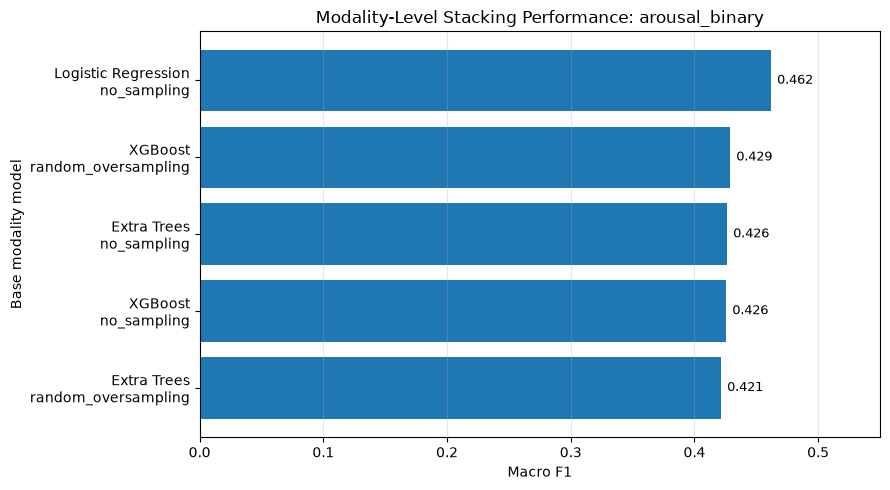

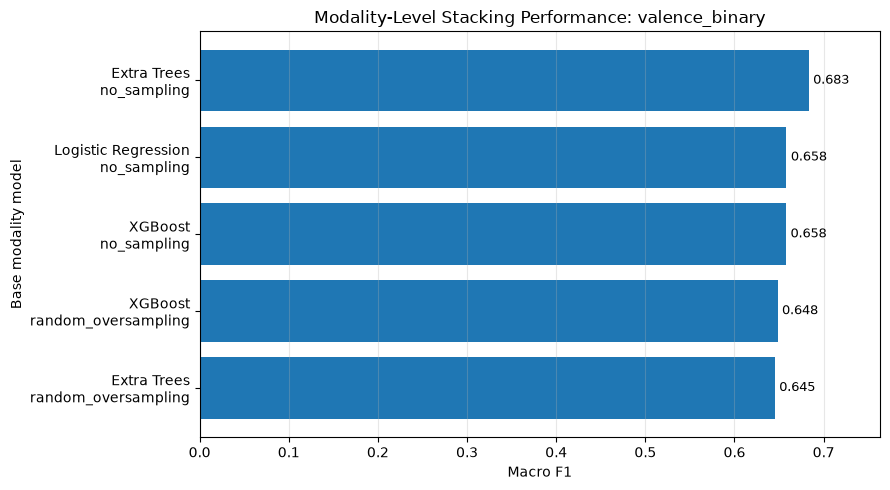

In [25]:
# Go prikazuva Macro F1 za sekoj eksperiment za stacking performansite pregledno da se sporedat megju tipovite modeli.
for target_name in stacking_results["target"].unique():
    plot_df = (
        stacking_results[
            stacking_results["target"] == target_name
        ]
        .sort_values("macro_f1", ascending=False)
        .sort_values("macro_f1", ascending=True)
    )

    labels = (
        plot_df["base_model"]
        + "\n"
        + plot_df["sampling"]
    )

    plt.figure(figsize=(9, 5))
    plt.barh(labels, plot_df["macro_f1"])

    plt.xlabel("Macro F1")
    plt.ylabel("Base modality model")
    plt.title(f"Modality-Level Stacking Performance: {target_name}")
    plt.grid(axis="x", alpha=0.3)

    for i, value in enumerate(plot_df["macro_f1"]):
        plt.text(
            value + 0.005,
            i,
            f"{value:.3f}",
            va="center",
            fontsize=9,
        )

    plt.xlim(0, max(0.55, plot_df["macro_f1"].max() + 0.08))
    plt.tight_layout()
    plt.show()

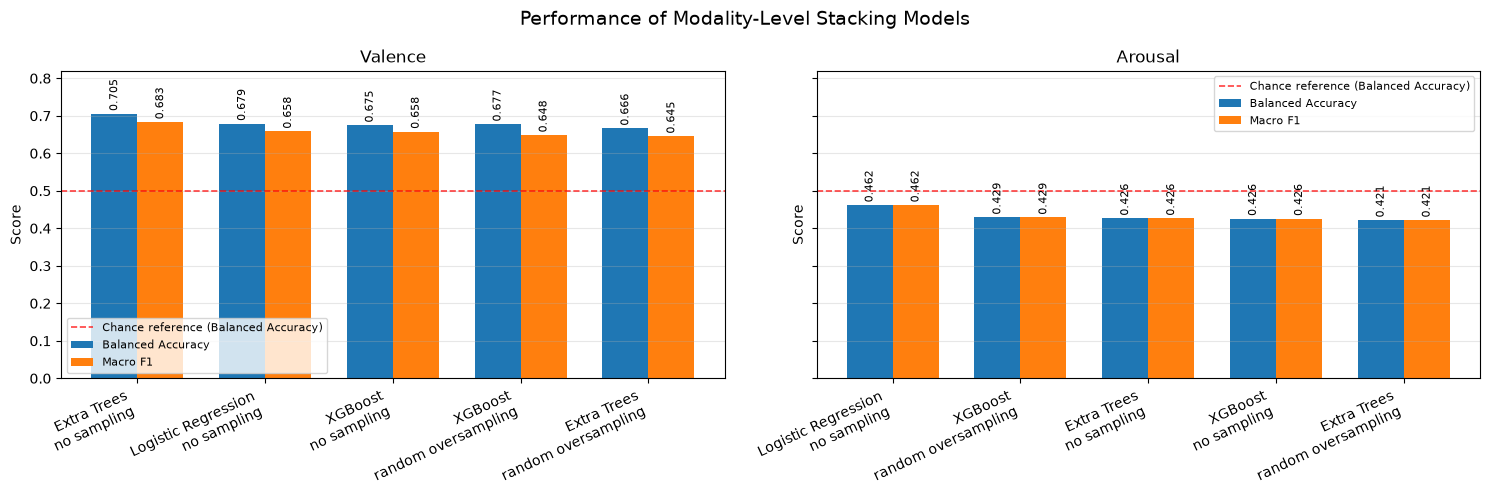

In [26]:
# Ovaa kletka gi sporeduva Balanced Accuracy i Macro F1 za site stacking eksperimenti, oddelno za valence i arousal.
metrics_to_plot = ["balanced_accuracy", "macro_f1"]
target_order = [
    target
    for target in ["valence_binary", "arousal_binary"]
    if target in stacking_results["target"].unique()
]

fig, axes = plt.subplots(
    1,
    len(target_order),
    figsize=(15, 5),
    sharey=True,
)
axes = np.atleast_1d(axes)

for ax, target_name in zip(axes, target_order):
    plot_df = (
        stacking_results[stacking_results["target"] == target_name]
        .copy()
        .sort_values("macro_f1", ascending=False)
    )

    labels = (
        plot_df["base_model"]
        + "\n"
        + plot_df["sampling"].str.replace("_", " ", regex=False)
    )

    x = np.arange(len(plot_df))
    width = 0.36

    balanced_bars = ax.bar(
        x - width / 2,
        plot_df["balanced_accuracy"],
        width,
        label="Balanced Accuracy",
    )
    macro_f1_bars = ax.bar(
        x + width / 2,
        plot_df["macro_f1"],
        width,
        label="Macro F1",
    )

    ax.axhline(
        0.5,
        color="red",
        linestyle="--",
        linewidth=1.2,
        alpha=0.75,
        label="Chance reference (Balanced Accuracy)",
    )

    ax.bar_label(balanced_bars, fmt="%.3f", padding=2, fontsize=8, rotation=90)
    ax.bar_label(macro_f1_bars, fmt="%.3f", padding=2, fontsize=8, rotation=90)
    ax.set_title(target_name.replace("_binary", "").capitalize())
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=25, ha="right")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 0.82)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=8)

fig.suptitle("Performance of Modality-Level Stacking Models", fontsize=14)
plt.tight_layout()
plt.show()

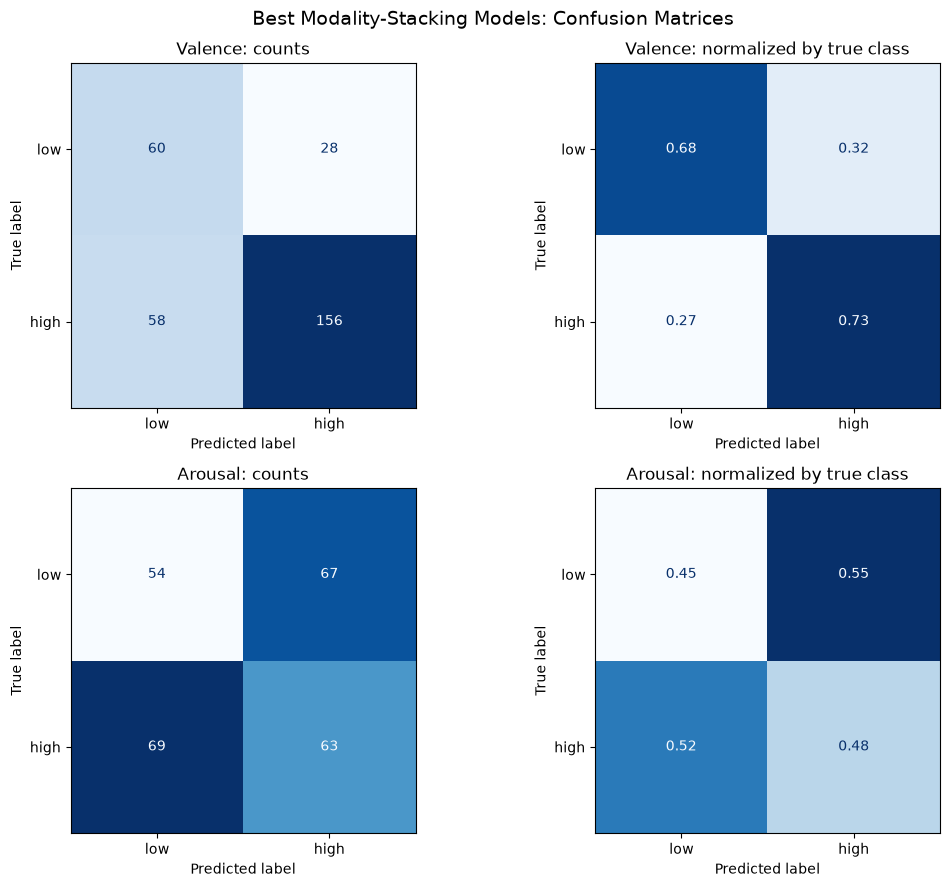

In [27]:
# Ovaa kletka prikazuva count i row-normalized confusion matrices za najdobriot stacking model za sekoj target.
target_artifacts = {
    "valence_binary": {
        "y_true": np.asarray(y_valence_binary),
        "predictions": valence_stacking_predictions,
    },
    "arousal_binary": {
        "y_true": np.asarray(y_arousal_binary),
        "predictions": arousal_stacking_predictions,
    },
}

best_rows_for_plot = (
    best_stacking_model_per_target
    .set_index("target")
    .loc[target_order]
    .reset_index()
)

fig, axes = plt.subplots(
    len(best_rows_for_plot),
    2,
    figsize=(11, 4.5 * len(best_rows_for_plot)),
)
axes = np.atleast_2d(axes)

for row_index, best_row in best_rows_for_plot.iterrows():
    target_name = best_row["target"]
    experiment_name = best_row["experiment"]
    artifacts = target_artifacts[target_name]
    prediction_data = artifacts["predictions"][(target_name, experiment_name)]
    y_true = artifacts["y_true"]
    y_pred = prediction_data["y_pred"]
    clean_target_name = target_name.replace("_binary", "").capitalize()

    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        labels=binary_label_order_numeric,
        display_labels=binary_label_order_names,
        values_format="d",
        cmap="Blues",
        colorbar=False,
        ax=axes[row_index, 0],
    )
    axes[row_index, 0].set_title(f"{clean_target_name}: counts")

    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        labels=binary_label_order_numeric,
        display_labels=binary_label_order_names,
        normalize="true",
        values_format=".2f",
        cmap="Blues",
        colorbar=False,
        ax=axes[row_index, 1],
    )
    axes[row_index, 1].set_title(f"{clean_target_name}: normalized by true class")

fig.suptitle("Best Modality-Stacking Models: Confusion Matrices", fontsize=14)
plt.tight_layout()
plt.show()

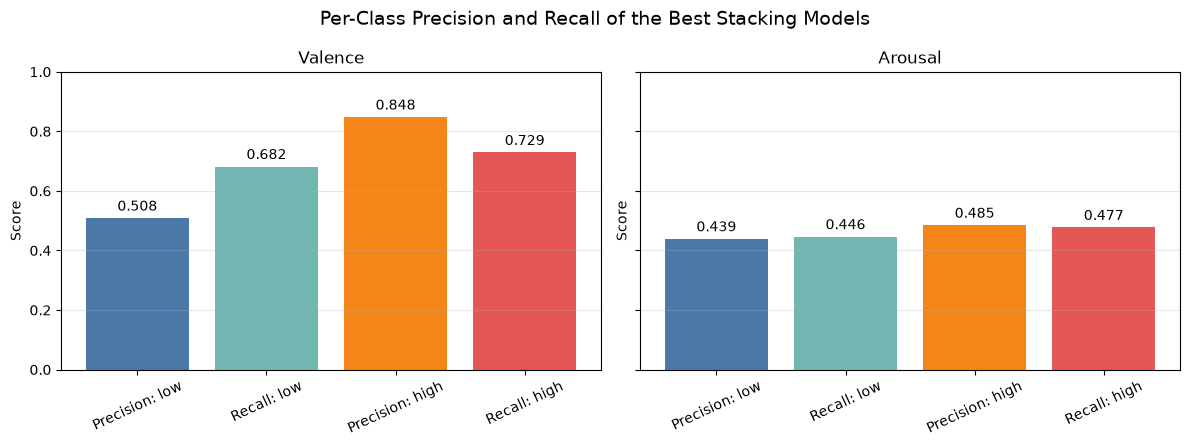

In [28]:
# Ovaa kletka gi sporeduva precision i recall za low i high klasata kaj najdobriot valence i arousal stacking model.
class_metric_columns = [
    "precision_low",
    "recall_low",
    "precision_high",
    "recall_high",
]
class_metric_labels = [
    "Precision: low",
    "Recall: low",
    "Precision: high",
    "Recall: high",
]
class_metric_colors = ["#4C78A8", "#72B7B2", "#F58518", "#E45756"]

fig, axes = plt.subplots(
    1,
    len(best_rows_for_plot),
    figsize=(12, 4.5),
    sharey=True,
)
axes = np.atleast_1d(axes)

for ax, (_, best_row) in zip(axes, best_rows_for_plot.iterrows()):
    values = best_row[class_metric_columns].astype(float).to_numpy()
    bars = ax.bar(class_metric_labels, values, color=class_metric_colors)

    ax.bar_label(bars, fmt="%.3f", padding=3)
    ax.set_title(best_row["target"].replace("_binary", "").capitalize())
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.0)
    ax.tick_params(axis="x", rotation=25)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Per-Class Precision and Recall of the Best Stacking Models", fontsize=14)
plt.tight_layout()
plt.show()

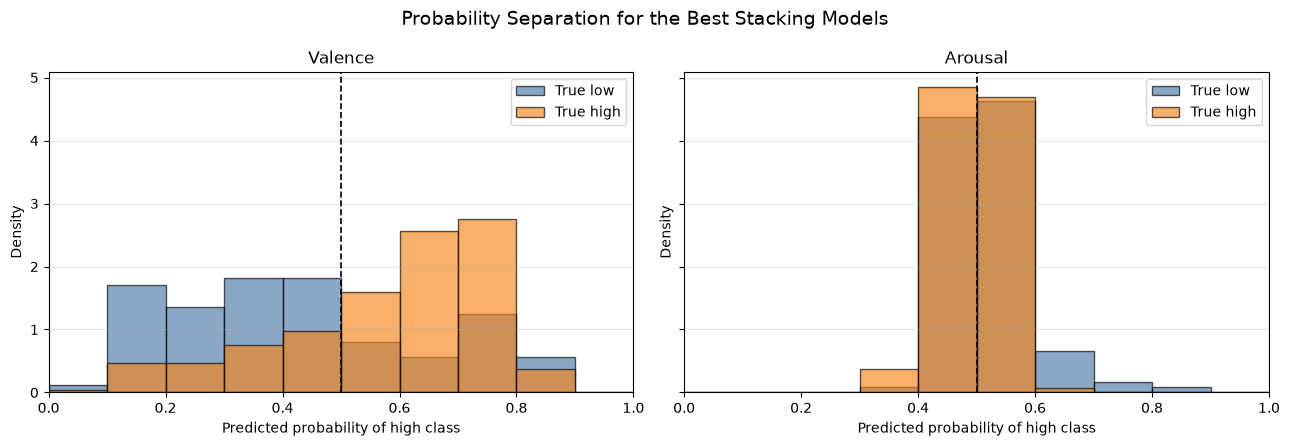

In [29]:
# Ovaa kletka ja prikazuva raspredelbata na predvidenata P(high) za vistinskite low i high primeroci kaj najdobrite modeli.
probability_bins = np.linspace(0, 1, 11)

fig, axes = plt.subplots(
    1,
    len(best_rows_for_plot),
    figsize=(13, 4.5),
    sharey=True,
)
axes = np.atleast_1d(axes)

for ax, (_, best_row) in zip(axes, best_rows_for_plot.iterrows()):
    target_name = best_row["target"]
    experiment_name = best_row["experiment"]
    artifacts = target_artifacts[target_name]
    prediction_data = artifacts["predictions"][(target_name, experiment_name)]
    y_true = artifacts["y_true"]
    y_proba_high = prediction_data["y_proba_high"]

    ax.hist(
        y_proba_high[y_true == 0],
        bins=probability_bins,
        alpha=0.65,
        density=True,
        label="True low",
        color="#4C78A8",
        edgecolor="black",
    )
    ax.hist(
        y_proba_high[y_true == 1],
        bins=probability_bins,
        alpha=0.65,
        density=True,
        label="True high",
        color="#F58518",
        edgecolor="black",
    )

    ax.axvline(0.5, color="black", linestyle="--", linewidth=1.2)
    ax.set_title(target_name.replace("_binary", "").capitalize())
    ax.set_xlabel("Predicted probability of high class")
    ax.set_ylabel("Density")
    ax.set_xlim(0, 1)
    ax.grid(axis="y", alpha=0.3)
    ax.legend()

fig.suptitle("Probability Separation for the Best Stacking Models", fontsize=14)
plt.tight_layout()
plt.show()

In [30]:
# Ja zacuvavuva finalnata tabela so stacking rezultati za tie da mozat povtorno da se koristat nadvor od notebook-ot.
STACKING_RESULTS_PATH = OUTPUT_DIR / "lopo_binary_modality_stacking_results.csv"

stacking_results.to_csv(STACKING_RESULTS_PATH, index=False)

print("Saved modality-stacking results to:")
print(STACKING_RESULTS_PATH)

Saved modality-stacking results to:
C:\Users\Kristina's PC\Desktop\EmteqPRO-VR\outputs\lopo_binary_modality_stacking_results.csv
